#Main Code Notebook group 15 coursework 1 CS3IV


In [2]:
#install required modules
# !pip install opencv-python
# !pip install matplotlib

#file paths in the cell below will need to be changed btw

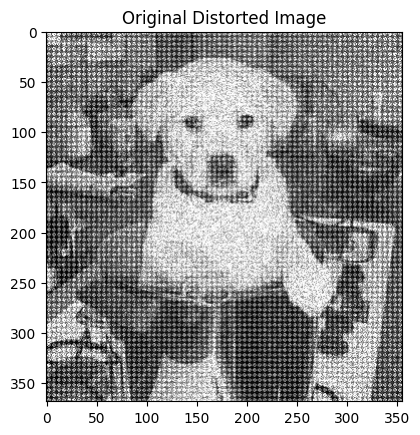

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# 1. Load the images
img = cv2.imread('dogDistorted.bmp', 0)
img_original = cv2.imread('dogOriginal.bmp', 0)

# 2. Safety check to make sure the image actually loaded
if img is None:
    print("Error: Could not find 'DogDistorted.bmp'")
else:
    # 3. Display the image
    plt.imshow(img, cmap='gray')
    plt.title('Original Distorted Image')
    plt.show()

#Step 1, FFT



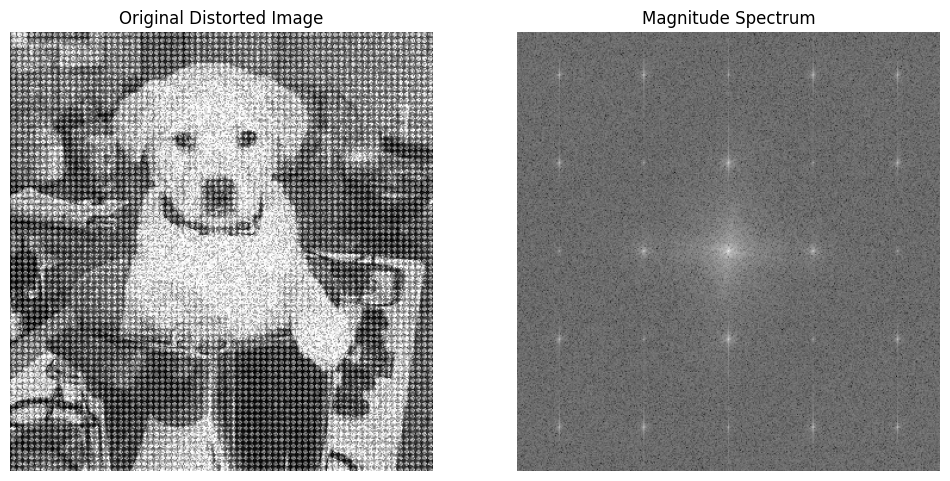

In [4]:
# Compute fft and display magnitude spectrum

# 1. Compute the 2-Dimensional Fast Fourier Transform (FFT)
# Converts the image from the spatial domain (pixels) to the frequency domain
f = np.fft.fft2(img)

# 2. Shift the zero-frequency component (DC component) to the center of the spectrum
fshift = np.fft.fftshift(f)

# 3. Calculate the magnitude spectrum
# np.abs is used to get the magnitude of complex numbers.
# 20 * np.log() is used to scale the values in order to be made visible.
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1) # (+1 is to avoid taking the log of 0)

# 4. Display the original image and its frequency spectrum
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Original Distorted Image'), plt.axis('off')

plt.subplot(122)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')

plt.show()



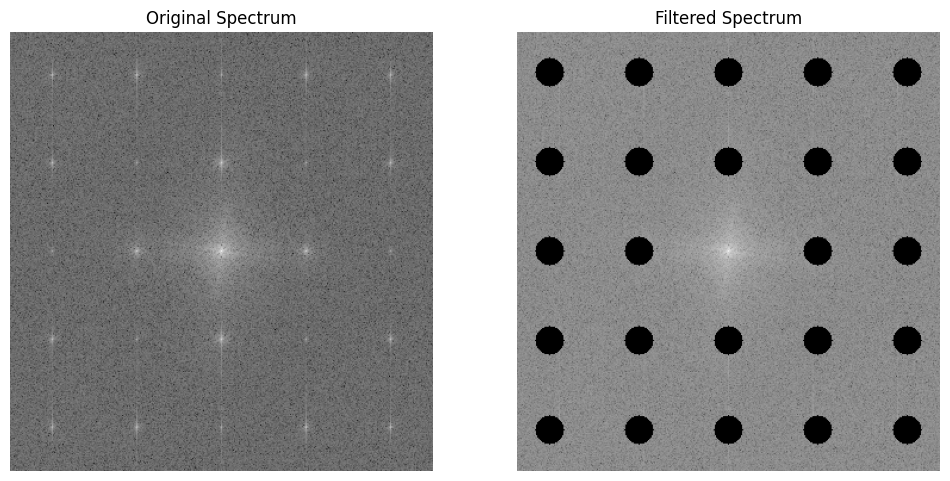

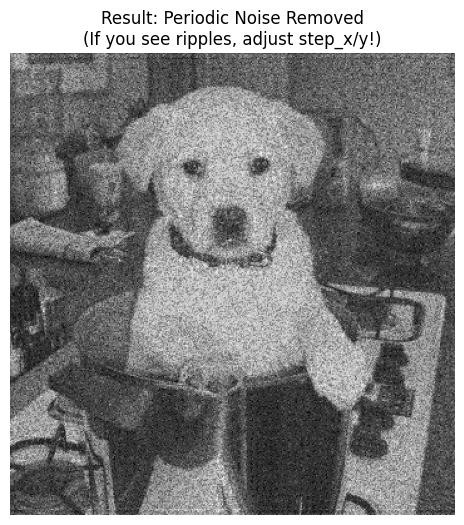

Image saved


In [5]:
# 5x5 notch filter

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# 1. Initialize the Notch Mask with 1s (Allow all frequencies to pass initially)
mask_notch = np.ones((rows, cols), np.uint8)

# 2. Set radius and position of the notches
r = 12  # Must be able to cover star but not too big to blur image.

step_y = 75  # Vertical distance between stars, tweaked until they lined up with the white stars, 75 works
step_x = 75  # Horizontal distance between stars

# 4. Loop to create a 5x5 grid of notches
for i in[-2, -1, 0, 1, 2]:
    for j in[-2, -1, 0, 1, 2]:
        # Must not block center
        if i == 0 and j == 0:
            continue

        # Calculate the center of each notch
        y = int(crow + (i * step_y))
        x = int(ccol + (j * step_x))

        # Draw a black circle (0) at that location
        cv2.circle(mask_notch, (x, y), r, 0, -1)

# 5. Apply the mask to the shifted FFT
fshift_notch = fshift * mask_notch

# visual alignment check
# Check the spectrum after the mask is applied to ensure the stars are gone
magnitude_spectrum_filtered = 20 * np.log(np.abs(fshift_notch) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Original Spectrum'), plt.axis('off')

plt.subplot(122)
plt.imshow(magnitude_spectrum_filtered, cmap='gray')
plt.title('Filtered Spectrum')
plt.axis('off')
plt.show()

# 6. Inverse FFT Process (Convert back to an image)
f_ishift_notch = np.fft.ifftshift(fshift_notch)
img_notch = np.fft.ifft2(f_ishift_notch)
img_notch = np.abs(img_notch)

# 7. display cleaned image
plt.figure(figsize=(8, 6))
plt.imshow(img_notch, cmap='gray')
plt.title('Result: Periodic Noise Removed\n(If you see ripples, adjust step_x/y!)')
plt.axis('off')
plt.show()

# Save for future steps
cv2.imwrite('Dog_Periodic_Removed.bmp', img_notch.astype(np.uint8))
print("Image saved")

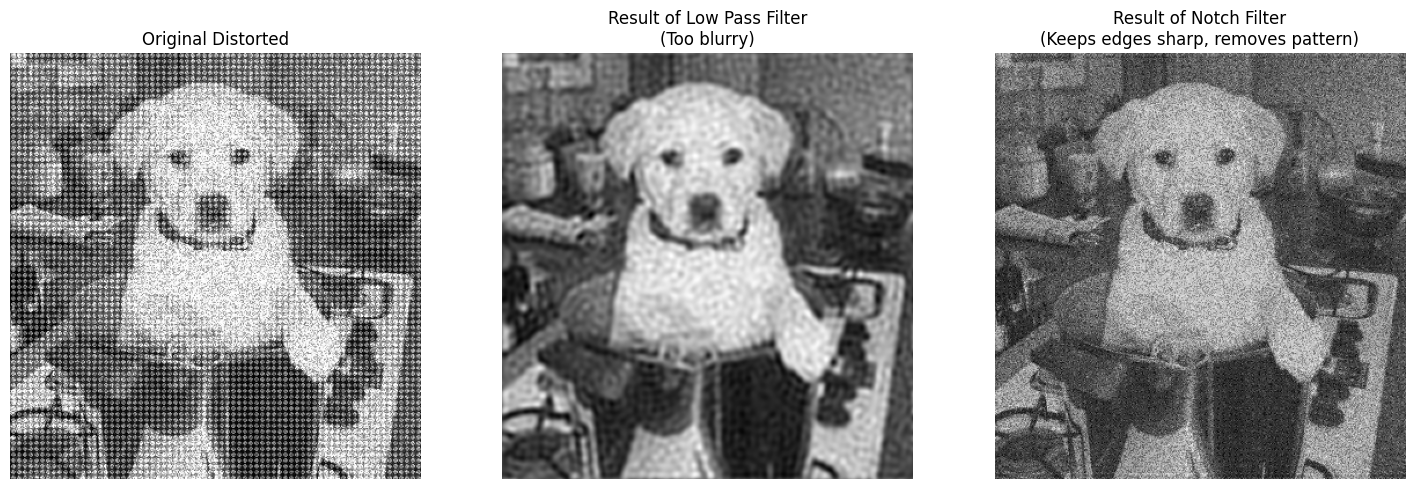

In [6]:
# Comparison with ideal low pass filter (ILPF)
# this will smooth over the distortion by blurring everthing, results will probably show that the FFT and


# This blocks ALL high frequencies, not just the noise spikes.
mask_ilpf = np.zeros((rows, cols), np.uint8)
cutoff_radius = 50 # Only allow frequencies within this radius to pass
cv2.circle(mask_ilpf, (ccol, crow), cutoff_radius, 1, -1)

# Apply ILPF mask and perform Inverse FFT
fshift_ilpf = fshift * mask_ilpf
f_ishift_ilpf = np.fft.ifftshift(fshift_ilpf)
img_ilpf = np.abs(np.fft.ifft2(f_ishift_ilpf))

# Display Side-by-Side Comparison
plt.figure(figsize=(18, 6))

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Original Distorted'), plt.axis('off')

plt.subplot(132), plt.imshow(img_ilpf, cmap='gray')
plt.title('Result of Low Pass Filter\n(Too blurry)'), plt.axis('off')

plt.subplot(133), plt.imshow(img_notch, cmap='gray')
plt.title('Result of Notch Filter\n(Keeps edges sharp, removes pattern)'), plt.axis('off')

plt.show()


The currently filtered image is saved as Dog_Periodic_Removed.bmp

In [7]:
# save results for future steps
cv2.imwrite('Dog_ILPF_Result.bmp', img_ilpf.astype(np.uint8))
cv2.imwrite('Dog_Notch_Result.bmp', img_notch.astype(np.uint8))
print("Images saved")

Images saved


# Step 2, Spatial Filtering

Input image shape: (369, 355)


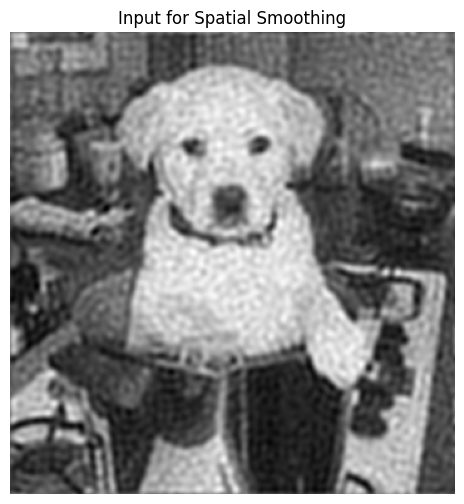

In [8]:
# Load the Image for future steps
img_to_filter = cv2.imread('Dog_ILPF_Result.bmp', 0)
print(f"Input image shape: {img_to_filter.shape}")
plt.figure(figsize=(6, 6))
plt.imshow(img_to_filter, cmap='gray')
plt.title('Input for Spatial Smoothing'), plt.axis('off')
plt.show()

In [9]:
# Spatial smoothing filters
# (local neighbourhood averaging / Gaussian / median)
kernel_size = 5 # Size of the kernel (must be odd), can be altered
sigma = 0.5  # Sigma for Gaussian blur, can be altered

# Mean (neighbourhood averaging)
# Takes the average of the pixel values in the kernel area, which can blur edges and details.
img_mean = cv2.blur(img_to_filter, (kernel_size, kernel_size))

# Median (edge-preserving smoothing compared with simple averaging)
# Takes the median of the pixel values in the kernel area, which can better preserve edges while reducing noise.
img_median = cv2.medianBlur(img_to_filter, kernel_size)

# Gaussian smoothing (most common practical smoothing filter)
# Applies a Gaussian blur, which weights the pixel values in the kernel area according to a Gaussian distribution,
# providing a balance between noise reduction and edge preservation.
img_gaussian = cv2.GaussianBlur(img_to_filter, (kernel_size, kernel_size), sigma)


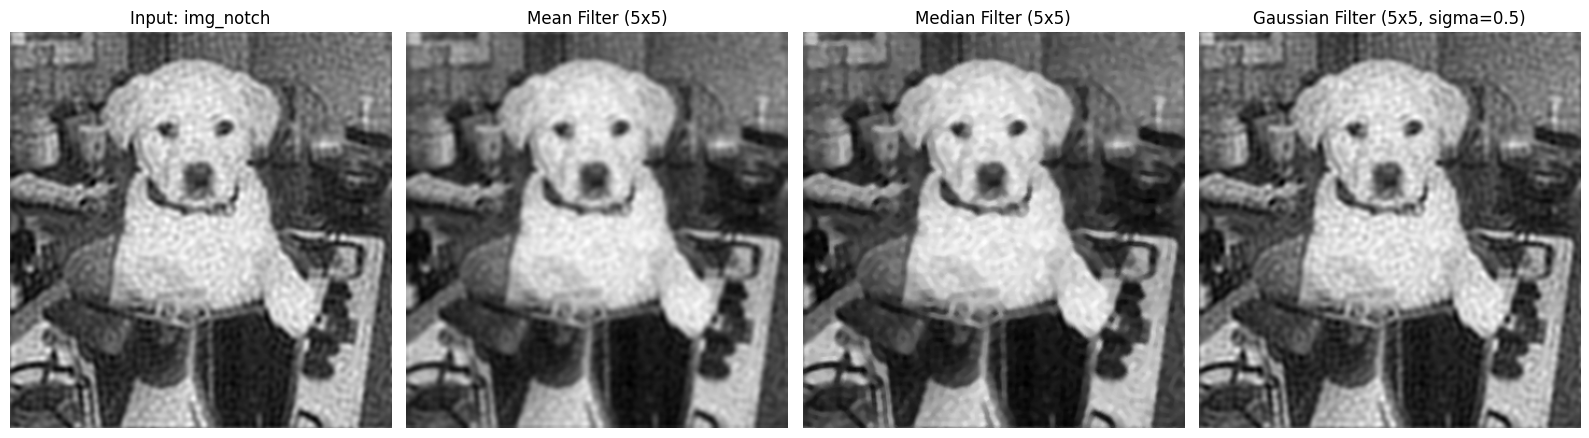

In [10]:
# Display Results
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

images = [img_to_filter, img_mean, img_median, img_gaussian]
titles = [
    'Input: img_notch',
    f'Mean Filter ({kernel_size}x{kernel_size})',
    f'Median Filter ({kernel_size}x{kernel_size})',
    f'Gaussian Filter ({kernel_size}x{kernel_size}, sigma={sigma})'
]

for ax, img_disp, title in zip(axes, images, titles):
    ax.imshow(img_disp, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


# Step 3 Evaluation / Results

In [11]:
import pandas as pd

def calculate_mse(original, processed):
    original = original.astype(np.float64)
    processed = processed.astype(np.float64)
    if original.shape != processed.shape:
        processed = cv2.resize(processed, (original.shape[1], original.shape[0])).astype(np.float64)
    return np.mean((original - processed) ** 2)

def calculate_psnr(mse, max_pixel=255.0):
    if mse == 0:
        return float('inf')
    return 10 * np.log10((max_pixel ** 2) / mse)

results = {
    'Distorted (baseline)':          img,
    'Frequency: Notch Filter':        img_notch,
    'Frequency: ILPF':                img_ilpf,
    'Frequency + Spatial: Mean':      img_mean,
    'Frequency + Spatial: Median':    img_median,
    'Frequency + Spatial: Gaussian':  img_gaussian,
}

mse_values, psnr_values = {}, {}
for label, image in results.items():
    mse = calculate_mse(img_original, image)
    psnr = calculate_psnr(mse)
    mse_values[label] = mse
    psnr_values[label] = psnr

df = pd.DataFrame({
    'Method': list(mse_values.keys()),
    'MSE': [round(v, 2) for v in mse_values.values()],
    'PSNR (dB)': [round(v, 2) for v in psnr_values.values()]
})

display(df)

,Method,MSE,PSNR (dB)
0,Distorted (baseline),4629.19,11.48
1,Frequency: Notch Filter,2674.61,13.86
2,Frequency: ILPF,1941.32,15.25
3,Frequency + Spatial: Mean,1908.87,15.32
4,Frequency + Spatial: Median,1888.96,15.37
5,Frequency + Spatial: Gaussian,1900.29,15.34


NameError: name 'mpatches' is not defined

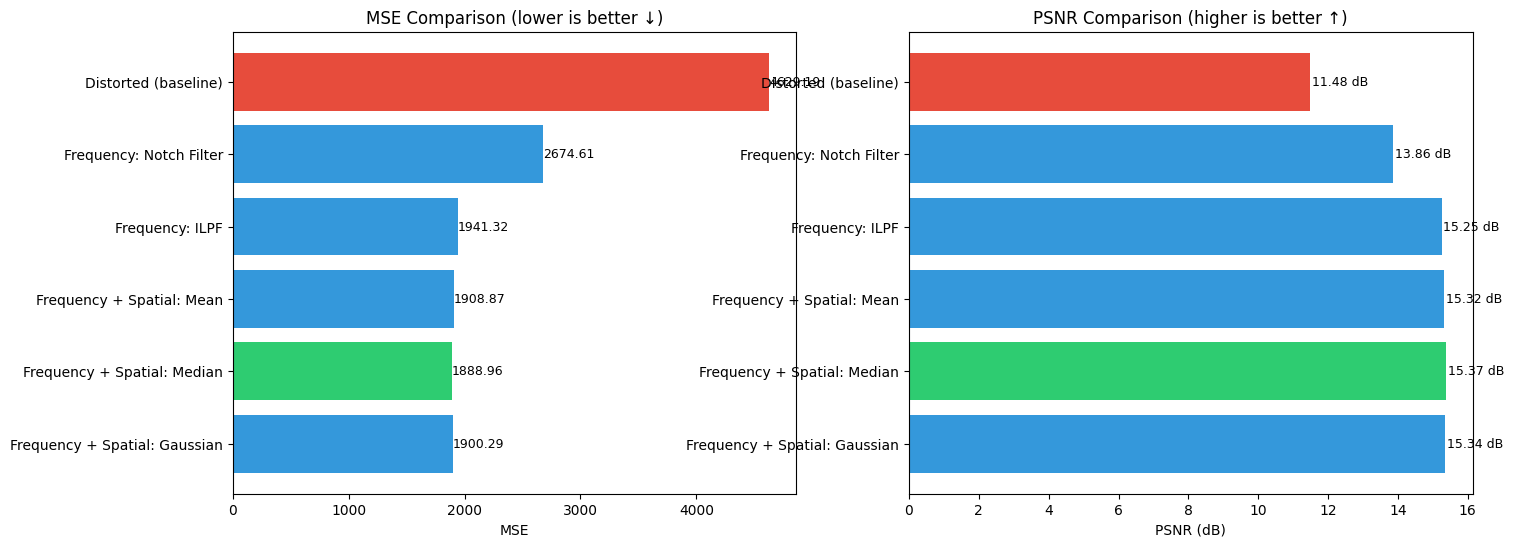

In [12]:
# Bar charts
labels    = list(mse_values.keys())
mse_vals  = list(mse_values.values())
psnr_vals = list(psnr_values.values())
best_label = min(mse_values, key=mse_values.get)
colours = ['#e74c3c' if l == 'Distorted (baseline)' else '#2ecc71' if l == best_label else '#3498db' for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(labels, mse_vals, color=colours)
axes[0].set_xlabel('MSE'), axes[0].set_title('MSE Comparison (lower is better ↓)')
axes[0].invert_yaxis()
for i, v in enumerate(mse_vals):
    axes[0].text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=9)

axes[1].barh(labels, psnr_vals, color=colours)
axes[1].set_xlabel('PSNR (dB)'), axes[1].set_title('PSNR Comparison (higher is better ↑)')
axes[1].invert_yaxis()
for i, v in enumerate(psnr_vals):
    axes[1].text(v + 0.05, i, f'{v:.2f} dB', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Distorted baseline'),
    mpatches.Patch(color='#2ecc71', label='Best result'),
    mpatches.Patch(color='#3498db', label='Other methods'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('MSE & PSNR Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Final image comparison
best_image = min(results, key=lambda k: mse_values[k])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_original, cmap='gray'), axes[0].set_title('Original'), axes[0].axis('off')
axes[1].imshow(img, cmap='gray'), axes[1].set_title(f'Distorted\nMSE = {mse_values["Distorted (baseline)"]:.2f}'), axes[1].axis('off')
axes[2].imshow(results[best_image], cmap='gray'), axes[2].set_title(f'Best: {best_image}\nMSE = {mse_values[best_image]:.2f}'), axes[2].axis('off')
plt.suptitle('Original vs Distorted vs Best Result', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()